<a href="https://colab.research.google.com/github/sushma-ravany/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction_using_Naive_Bayes_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction using Naive Bayes classifier



### Objective

The objective of this project is to predict the presence of heart disease using patient clinical data such as age, cholesterol level, blood pressure, heart rate, and other medical attributes.

### Dataset Information

The dataset contains medical records of patients along with a target variable indicating the presence or absence of heart disease.

Target Variable:
- 0 : No Heart Disease
- 1 : Heart Disease

Features:
- age
- sex
- cp
- trestbps
- chol
- fbs
- restecg
- thalach
- exang
- oldpeak
- slope
- ca
- thal

### Import Required Libraries

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Load and Explore Dataset

In [91]:
df = pd.read_csv('/content/heart.csv')

In [92]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [93]:
df.shape

(303, 14)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [95]:
#Check for null values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [96]:
#Check for duplicate records
df.duplicated().sum()

np.int64(1)

In [97]:
#Remove duplicate records
df.drop_duplicates(inplace = True)

In [98]:
df.shape

(302, 14)

In [99]:
df['target'].value_counts()

,count
target,
1,164
0,138


In [100]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

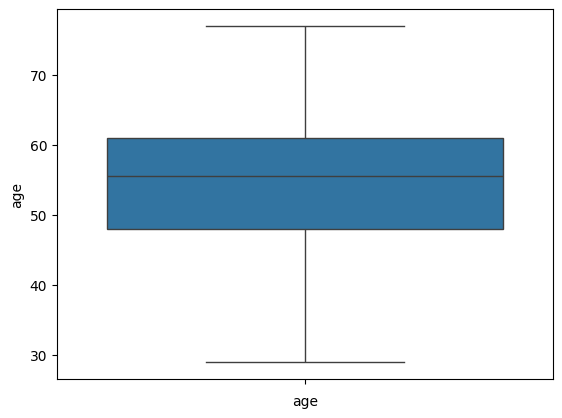

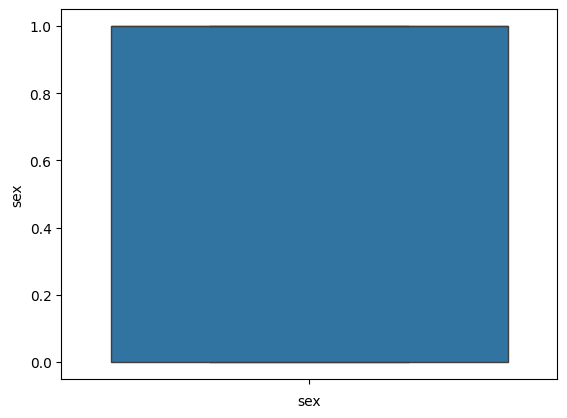

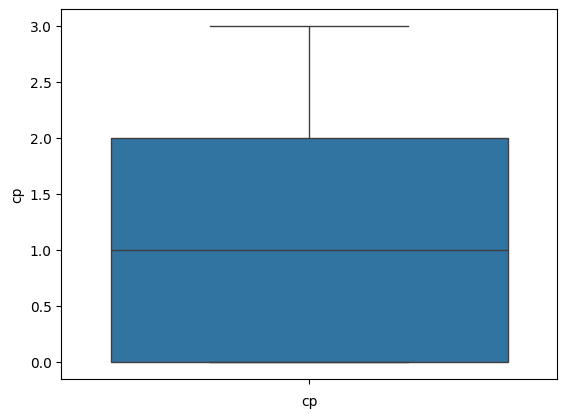

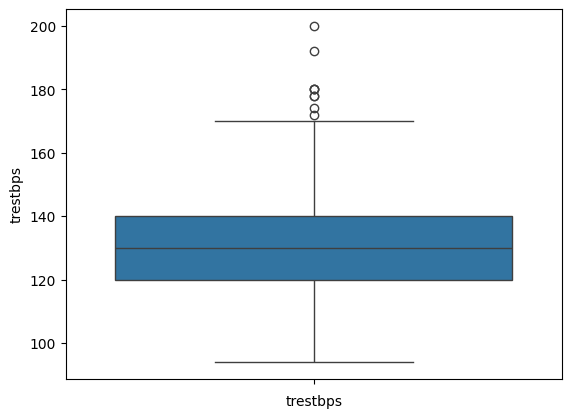

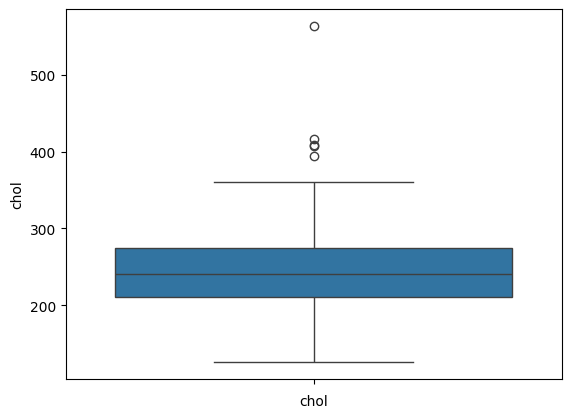

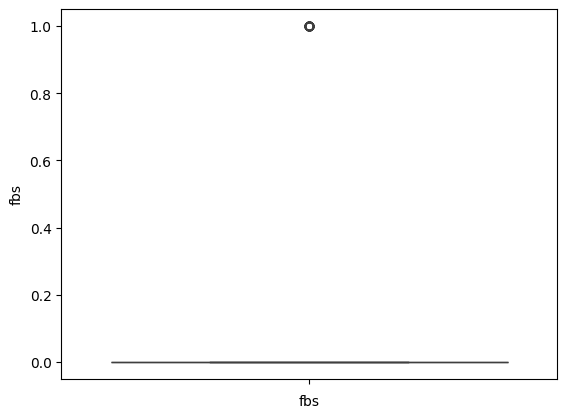

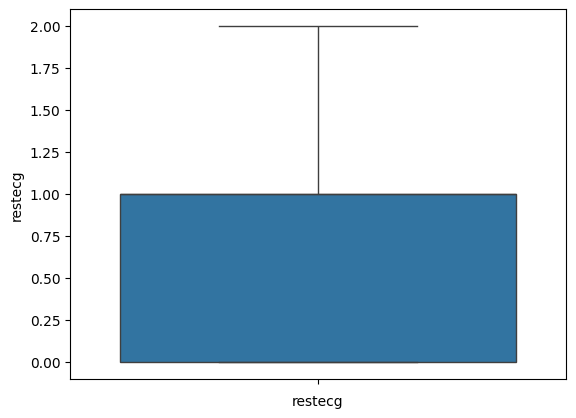

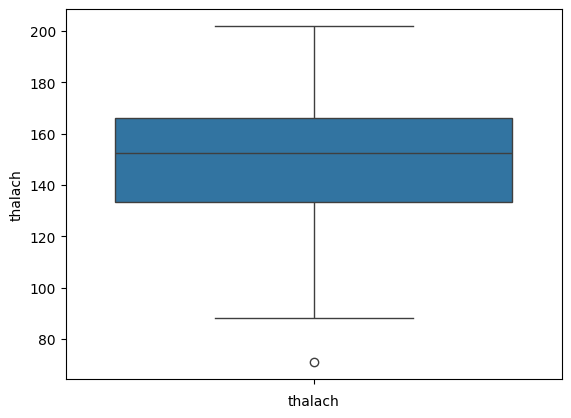

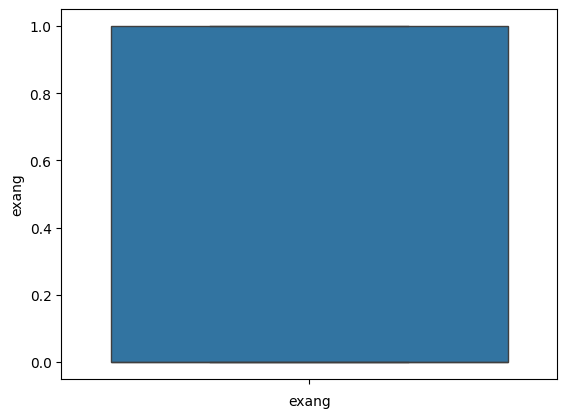

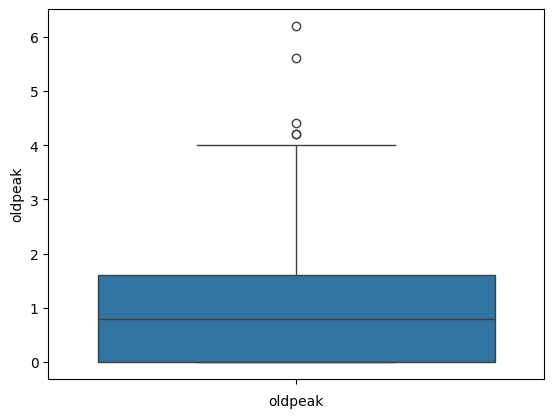

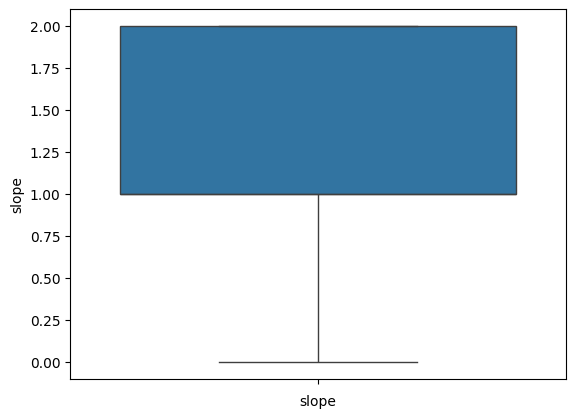

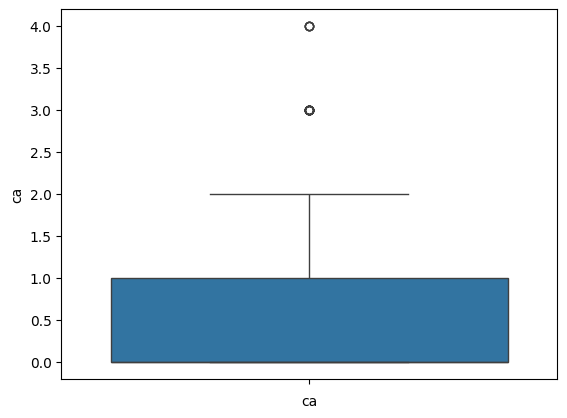

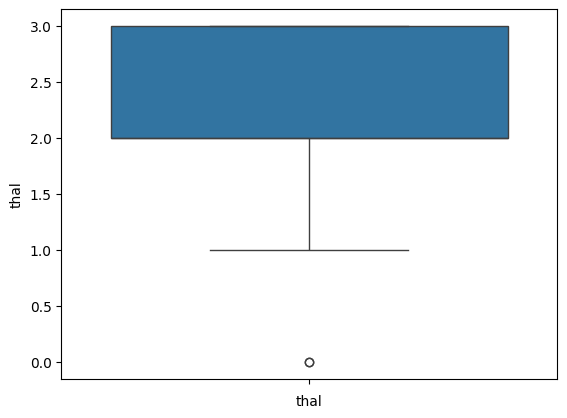

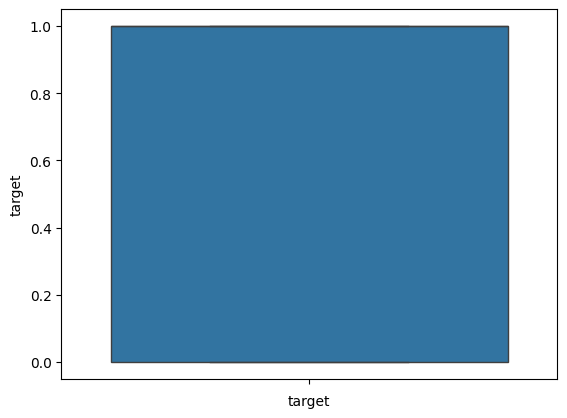

In [101]:
#Check for outliers
for col in df.columns:
  if df[col].dtype != 'object':
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

Outliers are retained in the dataset as they may represent valid medical observations rather than anomalies. Removing them could result in the loss of important information relevant to heart disease prediction.


### Feature and Target Separation

In [102]:
x = df.drop(columns = ['target'])
y = df['target']

### Train-Test-Split

In [103]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 21)

In [104]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((241, 13), (61, 13), (241,), (61,))

In [105]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
281,52,1,0,128,204,1,1,156,1,1.0,1,0,0
263,63,0,0,108,269,0,1,169,1,1.8,1,2,2
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
76,51,1,2,125,245,1,0,166,0,2.4,1,0,2
37,54,1,2,150,232,0,0,165,0,1.6,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
120,64,0,0,130,303,0,1,122,0,2.0,1,2,2
48,53,0,2,128,216,0,0,115,0,0.0,2,0,0
261,52,1,0,112,230,0,1,160,0,0.0,2,1,2


In [106]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
220,63,0,0,150,407,0,0,154,0,4.0,1,3,3
217,63,1,0,130,330,1,0,132,1,1.8,2,3,3
260,66,0,0,178,228,1,1,165,1,1.0,1,2,3
180,55,1,0,132,353,0,1,132,1,1.2,1,1,3
226,62,1,1,120,281,0,0,103,0,1.4,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44,39,1,2,140,321,0,0,182,0,0.0,2,0,2
129,74,0,1,120,269,0,0,121,1,0.2,2,1,2
272,67,1,0,120,237,0,1,71,0,1.0,1,0,2
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2


In [107]:
y_train

,target
281,0
263,0
60,1
76,1
37,1
...,...
189,0
120,1
48,1
261,0


In [108]:
y_test

,target
220,0
217,0
260,0
180,0
226,0
...,...
44,1
129,1
272,0
9,1


### Selection of model from among Naive Bayes variants

1. Multinomial Naive Bayes:  suited for count data
2. Bernoulli Naive Bayes:  intended for binary features
3. Gaussian Naive Bayes: for continuous numerical features

The values of features in this dataset is continuous. Hence using **Gaussian Naive bayes**

In [109]:
#Model Training
model = GaussianNB()
model.fit(x_train, y_train)

GaussianNB()

In [110]:
# Predictions
y_pred = model.predict(x_test)

### Model Evaluation

In [111]:
result = accuracy_score(y_test, y_pred)
print('Accuracy score: ', result*100)

Accuracy score:  81.9672131147541


In [112]:
print('Confusion Matrix: \n')
print(confusion_matrix(y_test,y_pred))


Confusion Matrix: 

[[28  4]
 [ 7 22]]


In [113]:
print('Classification report: \n')
print(classification_report(y_test,y_pred))

Classification report: 

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       0.85      0.76      0.80        29

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



### Results Interpretation

* The Gaussian Naive Bayes model achieved an accuracy of 81.97% on the test dataset.
* The model correctly classified 50 out of 61 patients.
* The model demonstrated balanced performance across both target classes.
* A precision score of 85% for heart disease prediction indicates that most positive predictions were accurate.
* The model achieved a recall of 76% for patients with heart disease, meaning that some diseased patients were not identified correctly.
* Future improvements could focus on increasing recall to reduce the number of false negatives.
